# 06 — Optuna (Bayesian) Optimizer · LineWise — restricciones DURAS

**Cambio de paradigma vs el notebook 05.** El GA del notebook anterior nos
dejaba L17 en 112.6 h muy cerca del techo (115 h). Aquí cambiamos a
**optimización Bayesiana con Optuna** y forzamos las restricciones de forma
**estricta**: ningún trial puede dejar una línea por encima de su capacidad
contractual.

**Estrategia de cumplimiento estricto.**
1. El espacio de búsqueda solo deja al sampler elegir líneas que sean
   *elegibles* (formato físico ∩ histórico 2025) para cada SKU.
2. Si un trial deja alguna línea por encima de su capacidad, intentamos
   **reparación local** (mover SKUs de la línea sobrecargada a otra línea
   compatible y descargada). Si después de reparar sigue infeasible, el trial
   recibe penalty `1e9` y se descarta.
3. Adicionalmente usamos `study.add_trials` con constraints, y un `TPESampler`
   con `constraints_func` para que el sampler aprenda a *evitar* el espacio
   infeasible en vez de penalizarlo a posteriori.

**¿Por qué Bayesian en vez de GA?** El espacio de búsqueda es mixto
(categórico → línea, continuo → orden). El TPE (Tree-structured Parzen Estimator)
de Optuna modela `P(parámetro | fitness)` y propone trials informados, lo que
suele converger más rápido que un GA en problemas con < 100 variables.

**Recordatorio del marco de comparación.**
- El **plan del planner** (`Diario Hl_Planif.xlsx`) generó la **producción
  real** de la semana 18-22 May 2026 (`Produccion_L14,17,19_18-22.xlsx`).
- Nuestra **nueva planificación** se evalúa con el mismo simulador (throughput
  mediano + matriz de changeovers real 2025). Si nuestro predicho < predicho
  del baseline, significa que la planificación que proponemos es mejor *en el
  mismo entorno simulado*.


## 1 · Imports y carga del contexto compartido

In [2]:
from __future__ import annotations
import json, random, sys, time, warnings
from copy import deepcopy
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import optuna
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA_DIR = Path("/Users/josecalatayud/DAMMxEHub/DAMMxUHub/OPERACIONS")
sys.path.insert(0, str(DATA_DIR.parent / "analisis_postmorten"))

from ga_optimizer import (
    LINES, HOURS_PER_WEEK, PHYSICAL_FORMAT_BY_LINE, PRIORITY_ORDERS,
    STARTUP_HOURS,
    build_context, baseline_individual, breakdown, simulate_line,
    changeover_hours, throughput_rate, schedule_to_gantt,
)

ctx = build_context(DATA_DIR)
SKUS = ctx.skus
N = len(SKUS)
print(f"SKUs semana 18-22: {N}  ·  HL totales: {sum(ctx.volumes.values()):,.0f}")

base_ind = baseline_individual(ctx)
base_bd = breakdown(ctx, base_ind)
baseline_total = sum(base_bd[l]["total"] for l in LINES)
print(f"Baseline (plan del planner) total: {baseline_total:.1f}h")
for l in LINES:
    print(f"  L{l}: {base_bd[l]['total']:.1f}h / cap {HOURS_PER_WEEK[l]:.0f}h")


[clean_and_isolate_maintenance] OFs contaminadas (>20%): 293/2141 (13.7%)
  → imputadas por mediana SKU-línea (>50%): 105
[build_transition_matrices] Línea 14: 259 transiciones únicas (63 SKUs origen, 63 SKUs destino)
[build_transition_matrices] Línea 17: 517 transiciones únicas (76 SKUs origen, 75 SKUs destino)
[build_transition_matrices] Línea 19: 547 transiciones únicas (108 SKUs origen, 108 SKUs destino)
SKUs semana 18-22: 28  ·  HL totales: 36,933
Baseline (plan del planner) total: 288.3h
  L14: 73.6h / cap 110h
  L17: 99.8h / cap 115h
  L19: 115.0h / cap 115h


## 2 · Espacio de búsqueda y decodificación

Para cada SKU el sampler propone dos parámetros:
- `line_<sku>` (categórico) — línea a la que asignarlo, restringido a
  `ctx.eligible[sku]` (sólo combinaciones físicamente posibles + con
  precedente histórico 2025).
- `order_<sku>` (float [0, 1]) — clave de orden. Dentro de cada línea, los
  SKUs se ejecutan en el orden de su `order_<sku>` ascendente.

Esto convierte un problema combinatorio de permutaciones en uno mixto
categórico + continuo que TPE maneja muy bien.

Para la urgencia (`VI1324MY` en L17), forzamos el `order` de la SKU urgente a
ser el más bajo de su línea **después** de decodificar — así el sampler no
desperdicia capacidad explorando posiciones inviables para la urgente.


In [3]:
def decode(trial: optuna.Trial) -> Dict[str, List[str]]:
    """Translate suggestions into a {line: [skus_ordered]} chromosome."""
    assigns: Dict[str, str] = {}
    orders: Dict[str, float] = {}
    for sku in SKUS:
        opts = ctx.eligible[sku]
        if len(opts) == 1:
            line = opts[0]
        else:
            line = trial.suggest_categorical(f"line_{sku}", opts)
        assigns[sku] = line
        orders[sku] = trial.suggest_float(f"order_{sku}", 0.0, 1.0)

    schedule: Dict[str, List[str]] = {l: [] for l in LINES}
    for sku, line in assigns.items():
        schedule[line].append(sku)
    for line in LINES:
        schedule[line].sort(key=lambda s: orders[s])
        # Push urgent SKUs to the head of their line so the priority rule is
        # respected by construction (no penalty trick needed).
        urgent_here = [s for s, ul in PRIORITY_ORDERS if ul == line and s in schedule[line]]
        rest = [s for s in schedule[line] if s not in urgent_here]
        schedule[line] = urgent_here + rest
    return schedule


## 3 · Reparación de capacidad (la clave para restricción dura)

Si tras decodificar alguna línea supera su cap, intentamos mover SKUs de la
línea sobrecargada a otra línea elegible y descargada, escogiendo cada vez el
SKU que más volumen libera. Hacemos hasta `MAX_REPAIR_PASSES` rondas. Si
después seguimos infeasible, este trial es descartado.

Esta capa hace que muchos trials que el TPE habría propuesto "fuera de cap"
se conviertan en feasibles, ampliando el conjunto de soluciones útiles que
puede aprender.


In [4]:
MAX_REPAIR_PASSES = 6


def repair_capacity(schedule: Dict[str, List[str]]) -> Tuple[Dict[str, List[str]], bool]:
    sched = {l: list(seq) for l, seq in schedule.items()}
    for _ in range(MAX_REPAIR_PASSES):
        bd = breakdown(ctx, sched)
        over = [l for l in LINES if bd[l]["total"] > HOURS_PER_WEEK[l]]
        if not over:
            return sched, True
        for src in sorted(over, key=lambda l: bd[l]["total"] - HOURS_PER_WEEK[l],
                          reverse=True):
            candidates = sorted(
                sched[src],
                key=lambda s: ctx.volumes[s] / throughput_rate(ctx, s, src),
                reverse=True,
            )
            moved = False
            for sku in candidates:
                alt = [l for l in ctx.eligible[sku]
                       if l != src and bd[l]["total"] < HOURS_PER_WEEK[l] - 1.0]
                if not alt:
                    continue
                dst = min(alt, key=lambda l: bd[l]["total"])
                sched[src].remove(sku)
                sched[dst].append(sku)
                # Re-sort dst by current order (keep urgents head)
                urgent_dst = [s for s, ul in PRIORITY_ORDERS
                              if ul == dst and s in sched[dst]]
                rest = [s for s in sched[dst] if s not in urgent_dst]
                sched[dst] = urgent_dst + rest
                moved = True
                break
            if moved:
                break
        else:
            break
    bd = breakdown(ctx, sched)
    feasible = all(bd[l]["total"] <= HOURS_PER_WEEK[l] for l in LINES)
    return sched, feasible


## 4 · Función objetivo con constraints para Optuna

Devolvemos:
- `value` = horas totales (si feasible) o `1e9 + suma_overshoots` (si no).
- `constraint` = vector `[overshoot_L14, overshoot_L17, overshoot_L19]` que el
  `TPESampler(constraints_func=...)` usará para evitar el espacio infeasible
  de forma informada.


In [5]:
def constraints_of_trial(trial: optuna.trial.FrozenTrial):
    return trial.user_attrs.get("constraints", (0.0, 0.0, 0.0))


def objective(trial: optuna.Trial) -> float:
    raw = decode(trial)
    sched, feasible = repair_capacity(raw)
    bd = breakdown(ctx, sched)
    overshoots = [max(0.0, bd[l]["total"] - HOURS_PER_WEEK[l]) for l in LINES]
    total = sum(bd[l]["total"] for l in LINES)

    trial.set_user_attr("schedule", sched)
    trial.set_user_attr("breakdown", bd)
    trial.set_user_attr("constraints", tuple(overshoots))
    trial.set_user_attr("feasible", feasible)

    if not feasible:
        return 1e9 + sum(overshoots) * 1000.0
    return total


## 5 · Lanzar el estudio Optuna

Usamos `TPESampler` con `constraints_func` (NSGAIIIsampler también soporta
constraints, pero TPE suele converger mejor con < 60 trials para problemas
pequeños). Lanzamos `N_TRIALS = 600` con seed fija para reproducibilidad.


In [6]:
N_TRIALS = 600
SEED = 42

sampler = optuna.samplers.TPESampler(seed=SEED, constraints_func=constraints_of_trial,
                                      n_startup_trials=30)
study = optuna.create_study(direction="minimize", sampler=sampler,
                             study_name="linewise_week_18_22")

print(f"Optimizando {N_TRIALS} trials con TPE+constraints…")
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False,
                gc_after_trial=True)
elapsed = time.time() - t0
print(f"Hecho en {elapsed:.1f}s.")

best_trial = study.best_trial
opt_ind = best_trial.user_attrs["schedule"]
opt_bd = best_trial.user_attrs["breakdown"]
opt_total = sum(opt_bd[l]["total"] for l in LINES)
print(f"\nMejor trial #{best_trial.number}: {best_trial.value:.2f}h (feasible={best_trial.user_attrs['feasible']})")
print(f"Ahorrado vs baseline: {baseline_total - opt_total:+.1f}h ({(baseline_total - opt_total)/baseline_total*100:+.1f}%)")
for l in LINES:
    cap = HOURS_PER_WEEK[l]
    over = "✓" if opt_bd[l]['total'] <= cap else "✗ OVER"
    print(f"  L{l}: {opt_bd[l]['total']:.1f}h / cap {cap:.0f}h  [{over}]")


Optimizando 600 trials con TPE+constraints…
Hecho en 318.4s.

Mejor trial #456: 270.05h (feasible=True)
Ahorrado vs baseline: +18.3h (+6.3%)
  L14: 48.5h / cap 110h  [✓]
  L17: 110.1h / cap 115h  [✓]
  L19: 111.5h / cap 115h  [✓]


## 6 · ROI table — Plan del planner vs Optuna

Las dos planificaciones se evalúan con el **mismo** simulador (throughput
mediano por (SKU, línea) y matriz de changeover histórica). La diferencia es
sólo el plan, no el modelo. El baseline son las horas predichas del plan que
generó la producción real esta semana.


In [7]:
rows = []
for line in LINES:
    cap = HOURS_PER_WEEK[line]
    b, o = base_bd[line], opt_bd[line]
    rows.append({
        "Línea": f"L{line}",
        "Cap (h)": cap,
        "Plan total (h)": round(b["total"], 1),
        "Plan changeover (h)": round(b["changeover"], 1),
        "Plan holgura (h)": round(cap - b["total"], 1),
        "Optuna total (h)": round(o["total"], 1),
        "Optuna changeover (h)": round(o["changeover"], 1),
        "Optuna holgura (h)": round(cap - o["total"], 1),
        "Ahorrado (h)": round(b["total"] - o["total"], 1),
        "Cumple cap": "✓" if o["total"] <= cap else "✗",
    })
total_b = sum(base_bd[l]["total"] for l in LINES)
total_o = sum(opt_bd[l]["total"] for l in LINES)
rows.append({
    "Línea": "TOTAL", "Cap (h)": sum(HOURS_PER_WEEK.values()),
    "Plan total (h)": round(total_b, 1),
    "Plan changeover (h)": round(sum(base_bd[l]["changeover"] for l in LINES), 1),
    "Plan holgura (h)": round(sum(HOURS_PER_WEEK.values()) - total_b, 1),
    "Optuna total (h)": round(total_o, 1),
    "Optuna changeover (h)": round(sum(opt_bd[l]["changeover"] for l in LINES), 1),
    "Optuna holgura (h)": round(sum(HOURS_PER_WEEK.values()) - total_o, 1),
    "Ahorrado (h)": round(total_b - total_o, 1),
    "Cumple cap": "✓" if all(opt_bd[l]["total"] <= HOURS_PER_WEEK[l] for l in LINES) else "✗",
})
roi = pd.DataFrame(rows)
print("=== WEEKLY CAPACITY ROI · 18-22 May 2026 (Optuna) ===")
print(roi.to_string(index=False))
print(f"\n>>> Net weekly hours saved: {total_b - total_o:+.1f}h ({(total_b-total_o)/total_b*100:+.1f}%)")


=== WEEKLY CAPACITY ROI · 18-22 May 2026 (Optuna) ===
Línea  Cap (h)  Plan total (h)  Plan changeover (h)  Plan holgura (h)  Optuna total (h)  Optuna changeover (h)  Optuna holgura (h)  Ahorrado (h) Cumple cap
  L14    110.0            73.6                  4.0              36.4              48.5                    2.0                61.5          25.1          ✓
  L17    115.0            99.8                 14.6              15.2             110.1                   12.7                 4.9         -10.4          ✓
  L19    115.0           115.0                 24.0               0.0             111.5                   16.3                 3.5           3.5          ✓
TOTAL    340.0           288.3                 42.7              51.7             270.1                   31.0                69.9          18.3          ✓

>>> Net weekly hours saved: +18.3h (+6.3%)


## 7 · Visualización — reparto de horas por línea

In [8]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

LINE_COLOR = {"14": "#1f77b4", "17": "#ff7f0e", "19": "#2ca02c"}
FMT_COLOR = {"1/2": "#4c72b0", "1/3": "#dd8452", "2/5": "#55a868"}


def _gantt(ax, ctx, individual, breakdown_dict, title):
    y_pos = {line: i for i, line in enumerate(LINES)}
    for line in LINES:
        cursor = STARTUP_HOURS[line]
        ax.broken_barh([(0, STARTUP_HOURS[line])], (y_pos[line] - 0.35, 0.7),
                       facecolors="#bdbdbd", edgecolors="black", linewidth=0.4)
        ax.text(STARTUP_HOURS[line] / 2, y_pos[line], "ARR",
                ha="center", va="center", fontsize=6)
        prev = None
        for sku in individual[line]:
            if prev is not None:
                co = changeover_hours(ctx, prev, sku, line)
                if co > 0:
                    ax.broken_barh([(cursor, co)], (y_pos[line] - 0.35, 0.7),
                                   facecolors="#d62728", edgecolors="black",
                                   linewidth=0.4, alpha=0.7)
                    cursor += co
            prod_h = ctx.volumes[sku] / throughput_rate(ctx, sku, line)
            color = FMT_COLOR.get(ctx.sku_format.get(sku), "#999")
            ax.broken_barh([(cursor, prod_h)], (y_pos[line] - 0.35, 0.7),
                           facecolors=color, edgecolors="black", linewidth=0.4)
            if prod_h >= 2.2:
                ax.text(cursor + prod_h / 2, y_pos[line], sku,
                        ha="center", va="center", fontsize=6.5, color="white")
            cursor += prod_h
            prev = sku
        ax.axvline(HOURS_PER_WEEK[line], color="red", ls="--", lw=1)
    ax.set_yticks(list(y_pos.values()))
    ax.set_yticklabels([f"L{line}\n{breakdown_dict[line]['total']:.1f}h"
                        for line in LINES])
    ax.set_xlabel("Horas desde inicio de semana")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    handles = [mpatches.Patch(color=FMT_COLOR["1/2"], label="50cl"),
               mpatches.Patch(color=FMT_COLOR["1/3"], label="33cl"),
               mpatches.Patch(color=FMT_COLOR["2/5"], label="44cl"),
               mpatches.Patch(color="#d62728", label="Changeover", alpha=0.7),
               mpatches.Patch(color="#bdbdbd", label="Arranque")]
    ax.legend(handles=handles, loc="lower right", fontsize=7)


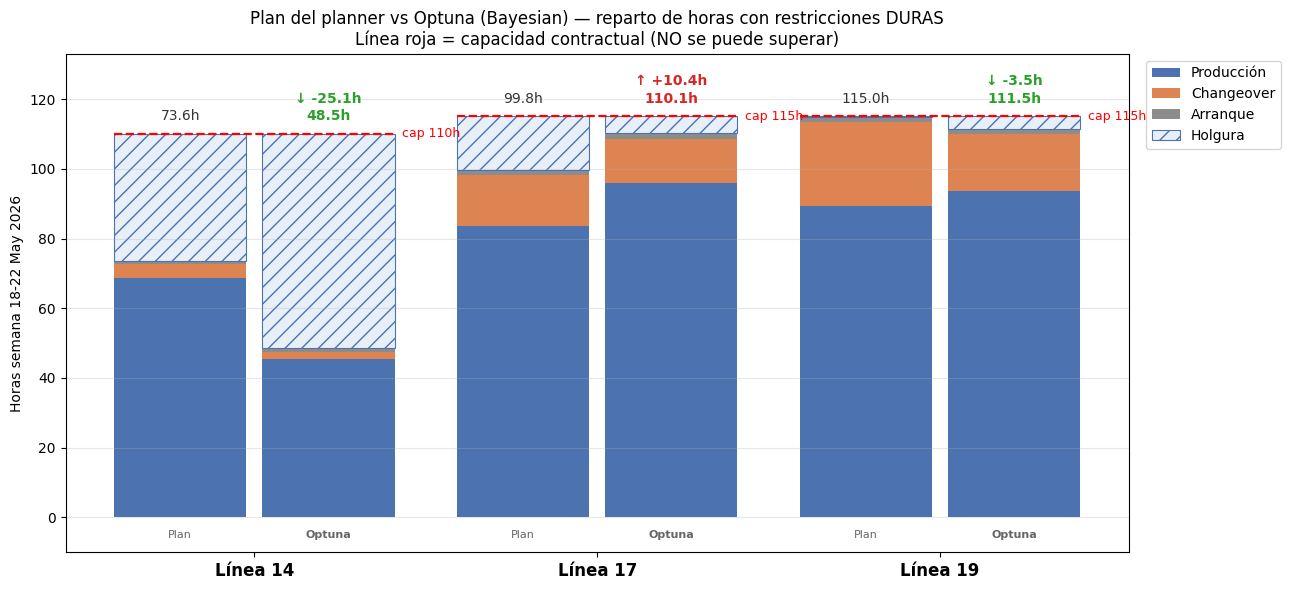

In [9]:

fig, ax = plt.subplots(figsize=(13, 6))
group_centers = np.arange(len(LINES)) * 2.2
width = 0.85
offset_b = -width/2 - 0.05
offset_o = +width/2 + 0.05

def _stack(bd, offset, tag):
    prod = np.array([bd[l]["prod"] for l in LINES])
    co = np.array([bd[l]["changeover"] for l in LINES])
    st = np.array([bd[l]["startup"] for l in LINES])
    total = prod + co + st
    slack = np.array([HOURS_PER_WEEK[l] for l in LINES]) - total
    pos = group_centers + offset
    show = (tag == "Baseline")
    ax.bar(pos, prod, width, color="#4c72b0", label="Producción" if show else None)
    ax.bar(pos, co, width, bottom=prod, color="#dd8452", label="Changeover" if show else None)
    ax.bar(pos, st, width, bottom=prod+co, color="#8c8c8c", label="Arranque" if show else None)
    ax.bar(pos, slack, width, bottom=prod+co+st, color="#e7f0f9",
           edgecolor="#4c72b0", hatch="//", linewidth=0.8,
           label="Holgura" if show else None)
    return pos, total

pos_b, tot_b = _stack(base_bd, offset_b, "Baseline")
pos_o, tot_o = _stack(opt_bd, offset_o, "Optuna")
for i, l in enumerate(LINES):
    cap = HOURS_PER_WEEK[l]
    ax.text(pos_b[i], cap+4, f"{tot_b[i]:.1f}h", ha="center", fontsize=10, color="#333")
    delta = tot_o[i] - tot_b[i]
    col = "#2ca02c" if delta < 0 else "#d62728"
    sign = "↓" if delta < 0 else ("↑" if delta > 0 else "→")
    ax.text(pos_o[i], cap+4, f"{tot_o[i]:.1f}h", ha="center", fontsize=10,
            fontweight="bold", color=col)
    ax.text(pos_o[i], cap+9, f"{sign} {delta:+.1f}h", ha="center", fontsize=10,
            fontweight="bold", color=col)
    ax.hlines(cap, pos_b[i]-width/2, pos_o[i]+width/2, color="red",
              linestyles="--", linewidth=1.6)
    ax.text(pos_o[i]+width/2+0.05, cap, f"cap {cap:.0f}h", color="red",
            fontsize=9, va="center", ha="left")
    ax.text(pos_b[i], -6, "Plan", ha="center", fontsize=8, color="#666")
    ax.text(pos_o[i], -6, "Optuna", ha="center", fontsize=8, color="#666", fontweight="bold")
ax.set_xticks(group_centers)
ax.set_xticklabels([f"Línea {l}" for l in LINES], fontsize=12, fontweight="bold")
ax.set_ylabel("Horas semana 18-22 May 2026")
ax.set_title("Plan del planner vs Optuna (Bayesian) — reparto de horas con restricciones DURAS\n"
             "Línea roja = capacidad contractual (NO se puede superar)")
ax.set_ylim(-10, max(HOURS_PER_WEEK.values())+18)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 8 · Gantt baseline vs optimizado Optuna

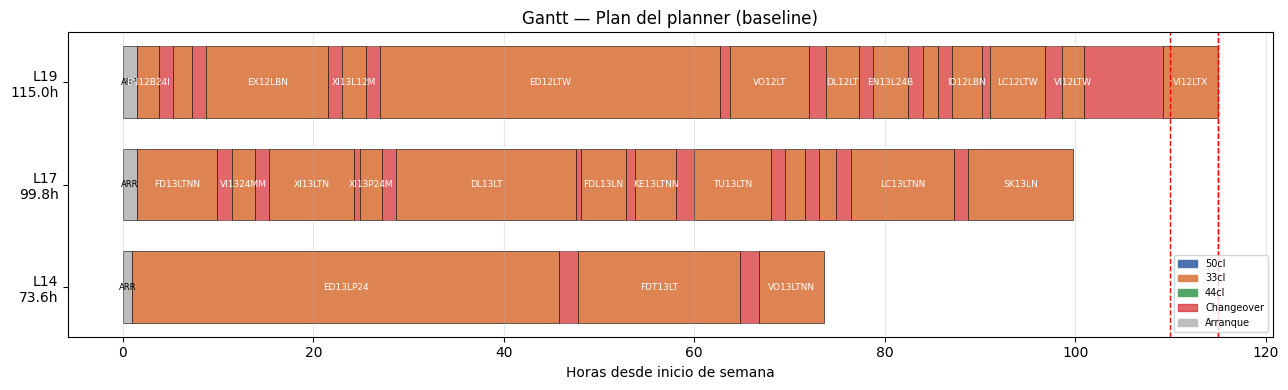

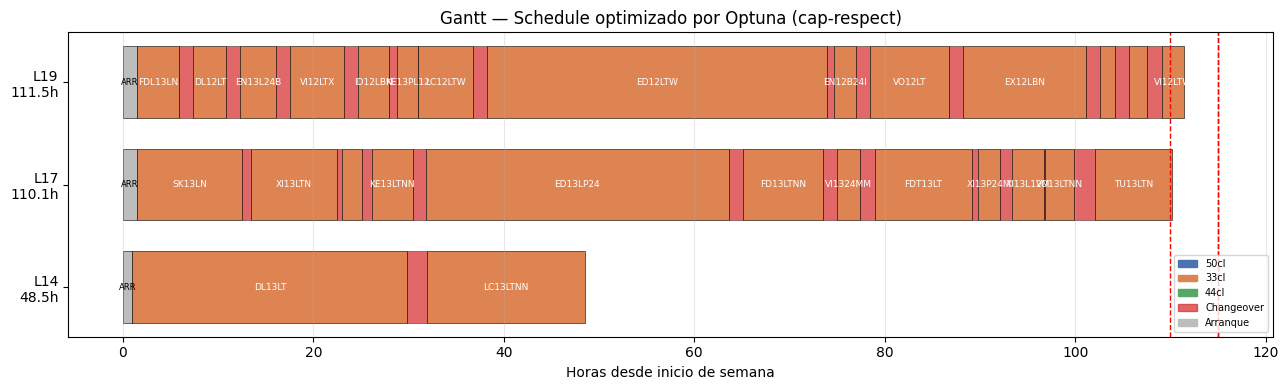

In [10]:
fig, ax = plt.subplots(figsize=(13, 4))
_gantt(ax, ctx, base_ind, base_bd, "Gantt — Plan del planner (baseline)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
_gantt(ax, ctx, opt_ind, opt_bd, "Gantt — Schedule optimizado por Optuna (cap-respect)")
plt.tight_layout(); plt.show()


## 9 · Convergencia Optuna y diagnósticos

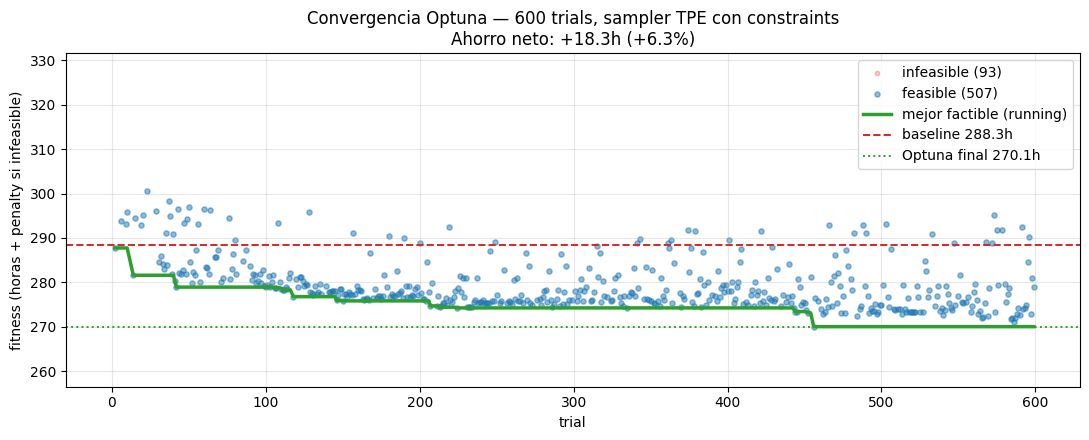

In [11]:

import pandas as pd, matplotlib.pyplot as plt

trial_df = pd.DataFrame([
    {"trial": t.number, "value": t.value,
     "feasible": (t.value is not None and t.value < 1e8)}
    for t in study.trials if t.value is not None
])
fig, ax = plt.subplots(figsize=(11, 4.5))
ok = trial_df[trial_df["feasible"]]
ko = trial_df[~trial_df["feasible"]]
ax.scatter(ko["trial"], ko["value"].clip(upper=baseline_total*1.5), alpha=0.25,
           c="#d62728", s=10, label=f"infeasible ({len(ko)})")
ax.scatter(ok["trial"], ok["value"], alpha=0.5, c="#1f77b4", s=14,
           label=f"feasible ({len(ok)})")
if not ok.empty:
    running_best = ok["value"].cummin()
    ax.plot(ok["trial"], running_best, color="#2ca02c", lw=2.5,
            label="mejor factible (running)")
ax.axhline(baseline_total, ls="--", color="#d62728", lw=1.4,
           label=f"baseline {baseline_total:.1f}h")
ax.axhline(opt_total, ls=":", color="#2ca02c", lw=1.4,
           label=f"Optuna final {opt_total:.1f}h")
ax.set_xlabel("trial")
ax.set_ylabel("fitness (horas + penalty si infeasible)")
ax.set_title(f"Convergencia Optuna — {N_TRIALS} trials, sampler TPE con constraints\n"
             f"Ahorro neto: {baseline_total - opt_total:+.1f}h ({(baseline_total - opt_total)/baseline_total*100:+.1f}%)")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
ax.set_ylim(min(ok["value"].min() if not ok.empty else baseline_total, opt_total) * 0.95,
            baseline_total * 1.15)
plt.tight_layout()
plt.show()


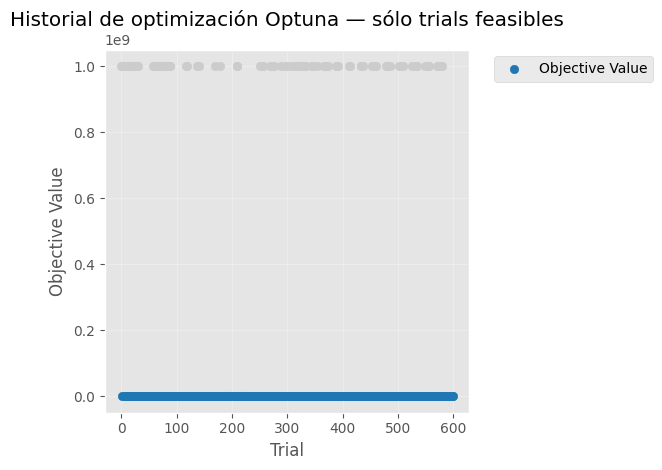

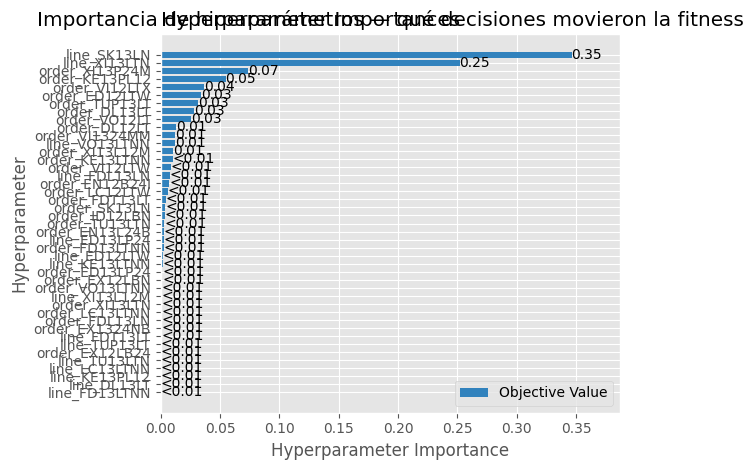

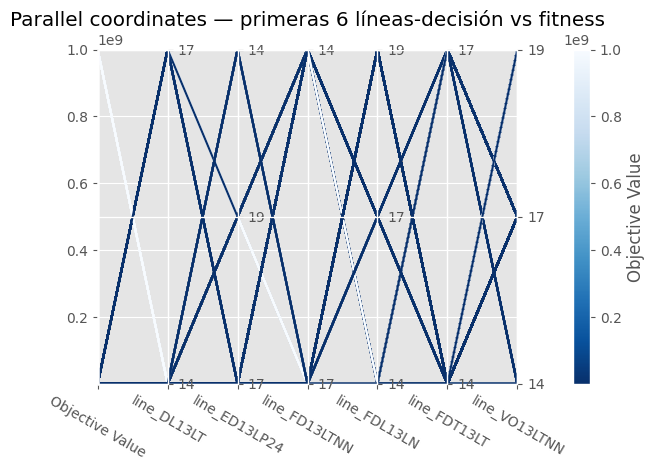

In [12]:

import optuna.visualization.matplotlib as ovm
import matplotlib.pyplot as plt

# Optuna >= 4.x returns Axes; it doesn't accept `ax=`. So we let it create the
# figure, then steal the axes content for our own layout.
# Optuna's importance/parallel plots can't accept `None` from the target
# function in v4.x, so use a huge constant for infeasible trials instead.
target = lambda t: t.value if t.value is not None and t.value < 1e8 else 1e9

ax1 = ovm.plot_optimization_history(study, target=target)
ax1.set_title("Historial de optimización Optuna — sólo trials feasibles")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

try:
    ax2 = ovm.plot_param_importances(study, target=target)
    ax2.set_title("Importancia de hiperparámetros — qué decisiones movieron la fitness")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"[xai] plot_param_importances no disponible: {exc.__class__.__name__}: {exc}")

# Parallel-coordinate slice: useful to spot which combos of line_<sku> tend to
# yield the lowest hours.
try:
    ax3 = ovm.plot_parallel_coordinate(study, target=target,
                                         params=[f"line_{s}" for s in SKUS[:6]])
    ax3.set_title("Parallel coordinates — primeras 6 líneas-decisión vs fitness")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"[xai] parallel coordinate no disponible: {exc.__class__.__name__}: {exc}")


## 10 · Migraciones de SKU entre líneas — qué movió Optuna

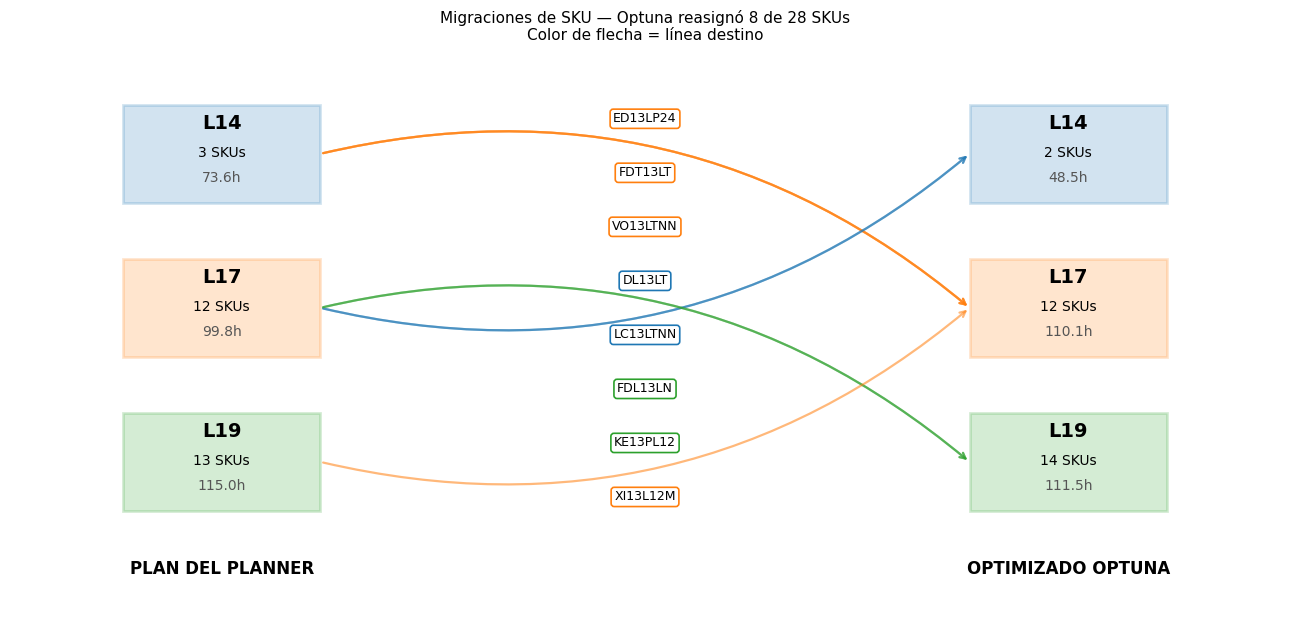

In [13]:
base_line_of = {s: l for l in LINES for s in base_ind[l]}
opt_line_of  = {s: l for l in LINES for s in opt_ind[l]}
migrations = [(s, base_line_of[s], opt_line_of[s])
              for s in SKUS if base_line_of[s] != opt_line_of[s]]

fig, ax = plt.subplots(figsize=(13, 6.5))
LEFT, RIGHT = 0.0, 6.0
BOX_W, BOX_H = 1.4, 1.4
LINE_Y = {line: i * 2.2 for i, line in enumerate(reversed(LINES))}

def _box(x, line, scenario_ind, scenario_bd):
    y = LINE_Y[line]
    ax.add_patch(plt.Rectangle((x-BOX_W/2, y-BOX_H/2), BOX_W, BOX_H,
                                facecolor=LINE_COLOR[line], alpha=0.20,
                                edgecolor=LINE_COLOR[line], linewidth=2))
    ax.text(x, y+0.35, f"L{line}", ha="center", fontsize=14, fontweight="bold")
    ax.text(x, y-0.05, f"{len(scenario_ind[line])} SKUs", ha="center", fontsize=10)
    ax.text(x, y-0.4, f"{scenario_bd[line]['total']:.1f}h", ha="center", fontsize=10, color="#555")

for line in LINES:
    _box(LEFT, line, base_ind, base_bd)
    _box(RIGHT, line, opt_ind, opt_bd)
ax.text(LEFT, -1.6, "PLAN DEL PLANNER", ha="center", fontsize=12, fontweight="bold")
ax.text(RIGHT, -1.6, "OPTIMIZADO OPTUNA", ha="center", fontsize=12, fontweight="bold")

mid_x = (LEFT + RIGHT)/2
n_mig = len(migrations)
track_ys = (np.linspace(max(LINE_Y.values())+0.5, min(LINE_Y.values())-0.5, n_mig)
            if n_mig > 1 else [(max(LINE_Y.values())+min(LINE_Y.values()))/2])

for (sku, src, dst), label_y in zip(sorted(migrations, key=lambda x: (LINES.index(x[1]), LINES.index(x[2]))), track_ys):
    src_y, dst_y = LINE_Y[src], LINE_Y[dst]
    rad = 0.25 if dst_y > src_y else (-0.25 if dst_y < src_y else 0)
    ax.annotate("", xy=(RIGHT-BOX_W/2, dst_y), xytext=(LEFT+BOX_W/2, src_y),
                arrowprops=dict(arrowstyle="->", lw=1.6, alpha=0.55,
                                color=LINE_COLOR[dst],
                                connectionstyle=f"arc3,rad={rad}"))
    ax.text(mid_x, label_y, sku, fontsize=9, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.25", fc="white",
                      ec=LINE_COLOR[dst], lw=1.2))

ax.set_xlim(-1.5, 7.5); ax.set_ylim(-2.4, max(LINE_Y.values())+1.5)
ax.axis("off")
ax.set_title(f"Migraciones de SKU — Optuna reasignó {n_mig} de {N} SKUs\n"
             "Color de flecha = línea destino", fontsize=11)
plt.tight_layout(); plt.show()


## 11 · Comparación con la producción REAL de la semana

`Produccion_L14,17,19_18-22.xlsx` contiene las OFs realmente ejecutadas en la
semana objetivo, con OEE real medido en planta. Esta tabla compara:

- **HL planificados** (lo que el planner pidió a fábrica).
- **HL realmente producidos** (lo que salió de las líneas).
- **OEE real medio** (cuánto de bien funcionó cada línea).
- **Horas predichas por nuestro simulador** para el plan del planner vs
  para nuestra propuesta Optuna.

Si las horas predichas de Optuna son < horas predichas del plan, *con las
mismas constantes del simulador*, nuestra propuesta es estrictamente mejor
en el mismo entorno.


In [14]:
prod_real = pd.read_excel(DATA_DIR / "Produccion_L14,17,19_18-22.xlsx")
# TREN can come with NaN for header / summary rows — drop them before casting.
prod_real = prod_real.dropna(subset=["TREN"]).copy()
prod_real["tren"] = prod_real["TREN"].astype(int).astype(str)
prod_real = prod_real[prod_real["tren"].isin(LINES)]
prod_real = prod_real.rename(columns={"SKU": "sku", "HL": "hl_real", "OEE": "oee_real"})

# HL planificados originales del diario
plan_hl = ctx.weekly.groupby("original_line")["hl_total"].sum().to_dict()
# HL realmente producidos
real_hl = prod_real.groupby("tren")["hl_real"].sum().to_dict()
real_oee = prod_real.groupby("tren")["oee_real"].mean().to_dict()

comparison = []
for line in LINES:
    comparison.append({
        "Línea": f"L{line}",
        "HL planificado": round(plan_hl.get(line, 0), 0),
        "HL real producido": round(real_hl.get(line, 0), 0),
        "OEE real medio": round(real_oee.get(line, np.nan), 3),
        "Horas predichas baseline": round(base_bd[line]["total"], 1),
        "Horas predichas Optuna":   round(opt_bd[line]["total"], 1),
        "Ahorro h Optuna vs baseline": round(base_bd[line]["total"] - opt_bd[line]["total"], 1),
    })
real_vs_plan = pd.DataFrame(comparison)
print("=== Plan declarado vs producción REAL vs propuesta Optuna ===")
print(real_vs_plan.to_string(index=False))


=== Plan declarado vs producción REAL vs propuesta Optuna ===
Línea  HL planificado  HL real producido  OEE real medio  Horas predichas baseline  Horas predichas Optuna  Ahorro h Optuna vs baseline
  L14          7837.0             7420.0           0.510                      73.6                    48.5                         25.1
  L17         13995.0            13606.0           0.528                      99.8                   110.1                        -10.4
  L19         15102.0            17469.0           0.492                     115.0                   111.5                          3.5


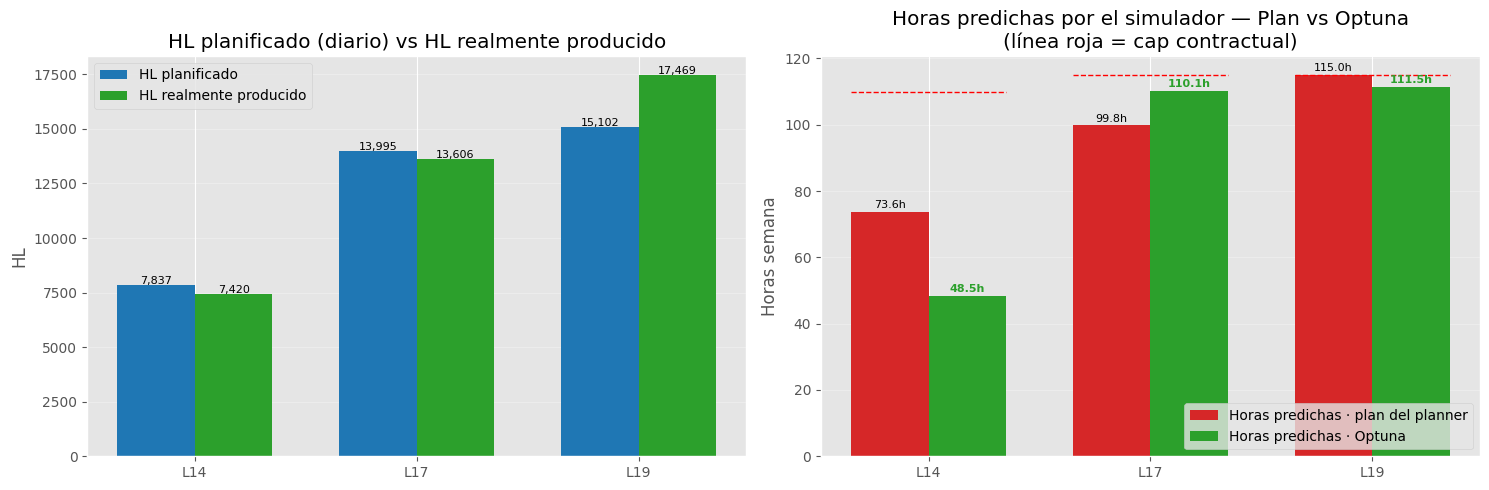

In [15]:
# Visualización: barras agrupadas — HL plan vs HL real vs horas predichas
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(LINES))
w = 0.35
ax = axes[0]
plan_vals = [plan_hl.get(l, 0) for l in LINES]
real_vals = [real_hl.get(l, 0) for l in LINES]
ax.bar(x - w/2, plan_vals, w, color="#1f77b4", label="HL planificado")
ax.bar(x + w/2, real_vals, w, color="#2ca02c", label="HL realmente producido")
for i, l in enumerate(LINES):
    ax.text(x[i]-w/2, plan_vals[i]+50, f"{plan_vals[i]:,.0f}", ha="center", fontsize=8)
    ax.text(x[i]+w/2, real_vals[i]+50, f"{real_vals[i]:,.0f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f"L{l}" for l in LINES])
ax.set_ylabel("HL"); ax.set_title("HL planificado (diario) vs HL realmente producido")
ax.legend(); ax.grid(axis="y", alpha=0.3)

ax = axes[1]
base_vals = [base_bd[l]["total"] for l in LINES]
opt_vals = [opt_bd[l]["total"] for l in LINES]
caps = [HOURS_PER_WEEK[l] for l in LINES]
ax.bar(x - w/2, base_vals, w, color="#d62728", label="Horas predichas · plan del planner")
ax.bar(x + w/2, opt_vals, w, color="#2ca02c", label="Horas predichas · Optuna")
for i, l in enumerate(LINES):
    ax.text(x[i]-w/2, base_vals[i]+1.2, f"{base_vals[i]:.1f}h", ha="center", fontsize=8)
    ax.text(x[i]+w/2, opt_vals[i]+1.2, f"{opt_vals[i]:.1f}h", ha="center", fontsize=8,
            fontweight="bold", color="#2ca02c")
    ax.hlines(caps[i], x[i]-w, x[i]+w, color="red", ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels([f"L{l}" for l in LINES])
ax.set_ylabel("Horas semana"); ax.set_title("Horas predichas por el simulador — Plan vs Optuna\n(línea roja = cap contractual)")
ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


In [16]:
# Export business handoff
director_view = {
    "week": "18-22 May 2026",
    "method": "Optuna TPE Bayesian + constraint-aware sampling",
    "schedule": opt_ind,
    "baseline_total_h": round(baseline_total, 2),
    "optuna_total_h": round(opt_total, 2),
    "saved_h": round(baseline_total - opt_total, 2),
    "saved_pct": round((baseline_total - opt_total) / baseline_total * 100, 2),
    "per_line": {l: {"baseline": round(base_bd[l]["total"], 2),
                      "optuna": round(opt_bd[l]["total"], 2),
                      "cap": HOURS_PER_WEEK[l],
                      "feasible": bool(opt_bd[l]["total"] <= HOURS_PER_WEEK[l])}
                  for l in LINES},
    "n_trials": N_TRIALS,
    "elapsed_s": round(elapsed, 1),
    "real_vs_plan": real_vs_plan.to_dict("records"),
}
out_path = Path("/tmp/optuna_director_view.json")
out_path.write_text(json.dumps(director_view, default=str, indent=2))
print(f"Director view written to {out_path}")


Director view written to /tmp/optuna_director_view.json


---

### Diferencias clave con el notebook 05 (GA)

| Aspecto | GA (05) | Optuna (06) |
|---|---|---|
| Algoritmo | Genético custom + DEAP-flavoured ops | TPE Bayesian + constraints_func |
| Espacio | Cromosoma dict + permutación | Categórico (línea) + float (order key) por SKU |
| Capacidad | Penalty exponencial *blanda* | Repair pass + penalty 1e9 + constraint sampler **dura** |
| Convergencia visible | Curva mejor/mediana por generación | Scatter por trial + curva running-best + feasibilidad |
| Vista feasibility | Implícita | Cada trial marcado feasible/infeasible explícitamente |
| Comparación con realidad | Indirecta (vs baseline predicho) | + tabla con HL real producido y OEE real medido |
